# Can a training lab support a USD 500 million GPU loan?

**A 10–15 minute financing case study.** How much capacity must the lab commit to paying customers, and how much can it retain for training?

The user-supplied deal discussion motivates the USD 1 billion equipment purchase, 50% advance and 1.5% arrangement fee. These are **unverified proposed terms**, not executed agreements. We anonymize the parties. The 17% rate and every operating, repayment and resale input below are **hypothetical modeling assumptions**, not quotes or forecasts. Prior fundraising is not assumed to be available project cash.

The borrower here is a **GPU-owning project**, with assumed ownership and security rights. It is not a capacity reseller. Internal training creates no external cash receipt in this model. The independent case supplements [F1](F1_financing_a_compute_prepayment.ipynb), [F4](F4_debt_capacity.ipynb) and [F8](F8_ownership_leasing_residual_value.ipynb); it does not implement the planned C1 capstone.

Use the repository's existing Python environment with `liquid_compute` installed. Edit the assumptions below; widgets are optional. Saved outputs show the worked examples without execution. Run the setup cell first in Colab, then edit the assumptions and run all cells.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from dataclasses import replace

from IPython.display import display

from liquid_compute.education import (
    lab_training_explorer,
    plot_lab_case,
    plot_lab_scenarios,
    show_lab_decision_summary,
    show_lab_scenario_comparison,
)
from liquid_compute.lab_financing import (
    LabInputs,
    liquidation_stress,
    minimum_contract_fraction,
    model_lab,
)

# Hypothetical base case; fractions are shares, not whole percentages.
base = LabInputs(
    equipment_usd=1_000_000_000,
    advance_fraction=0.50,
    gpu_count=32_000,
    hours_per_month=720,
    availability_fraction=0.95,
    training_fraction=0.40,
    contracted_fraction=0.40,
    contract_usd_per_gpu_hour=4.00,
    spot_usd_per_gpu_hour=2.00,
    spot_utilization_fraction=0.50,
    active_cost_usd_per_gpu_hour=0.60,
    fixed_cost_usd_per_month=3_000_000,
    nominal_annual_rate=0.17,
    term_months=60,
    repayment="level",  # Equal monthly payments; alternative: "balloon".
    fee_fraction=0.015,
    reserve_months=3,
    deployment_delay_months=0,
    support_cash_usd=0,  # Separately committed operating support only.
    minimum_dscr=1.25,
    annual_value_retention_fraction=0.65,
    liquidation_haircut_fraction=0.25,
    selling_cost_fraction=0.10,
    recovery_delay_months=6,
)

## 1. Separate the purchase from its cash requirements

The **advance rate** is loan principal divided by equipment cost. At time zero the project pays for and owns the equipment, draws the entire loan, and receives purchase equity. Fees and the locked debt-service reserve require additional equity. The reserve equals the first three scheduled debt payments and remains unavailable throughout this simplified model; it earns no interest and is not released here.

Interest accrues at the nominal annual rate divided by 12. Loan payments begin at month 1 even if operations are delayed. We use F1's equal-payment loan engine. This differs from equal principal repayment: USD 85 million of annual interest on the initial balance is a scale check, not the actual first-year amortizing interest bill.

Purchase equity: USD 500.0m
Fee on loan amount: USD 7.5m
Equal monthly payment: USD 12.43m


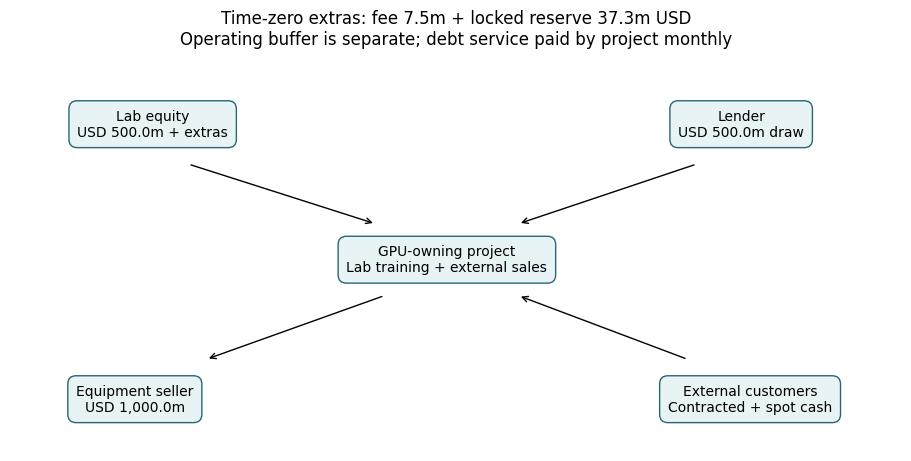

In [3]:
principal = base.equipment_usd * base.advance_fraction
purchase_equity = base.equipment_usd - principal
fee = principal * base.fee_fraction
monthly_rate = base.nominal_annual_rate / 12
payment = (
    principal / base.term_months
    if monthly_rate == 0
    else principal * monthly_rate / (1 - (1 + monthly_rate) ** -base.term_months)
)
print(f"Purchase equity: USD {purchase_equity / 1e6:,.1f}m")
print(f"Fee on loan amount: USD {fee / 1e6:,.1f}m")
print(f"Equal monthly payment: USD {payment / 1e6:,.2f}m")
result = model_lab(base)
display(plot_lab_case(base, view="structure"))

The base case requires USD 500 million of equipment equity, a USD 7.50 million fee and a USD 37.28 million locked reserve: **USD 544.78 million of initial equity in total**. The monthly payment is USD 12.43 million. The USD 1 billion purchase alone therefore understates the cash needed to close.

## 2. Allocate capacity before estimating cash

Each modeled month has 720 hours; this is a simplifying assumption, not a calendar. Usable hours equal GPU count × hours × availability. Training and committed shares refer to that usable total; spot utilization applies only to the remaining capacity. The example assumes a committed buyer pays for every reserved hour once capacity is available. No credit rating or enforceability is inferred from a signature.

Usable capacity: 21.888m GPU-hours/month
External cash less operating costs: USD 24.58m/month


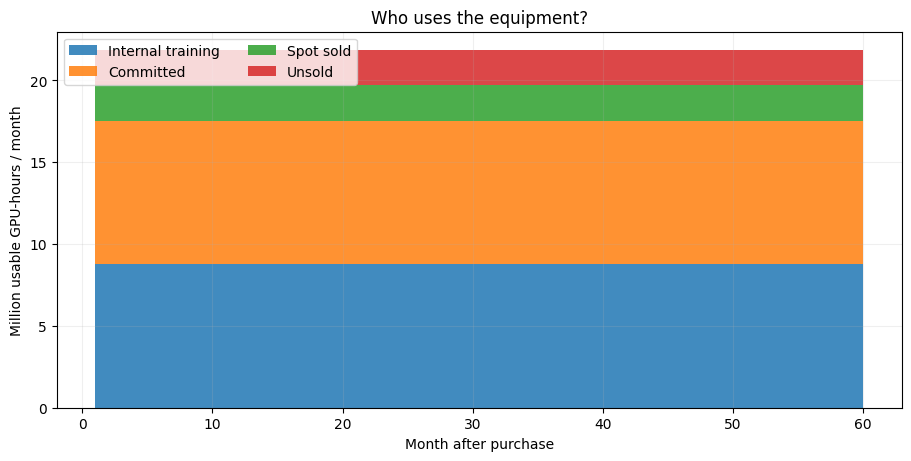

In [4]:
usable_hours = base.gpu_count * base.hours_per_month * base.availability_fraction
training_hours = usable_hours * base.training_fraction
committed_hours = usable_hours * base.contracted_fraction
remaining_hours = usable_hours - training_hours - committed_hours
spot_hours = remaining_hours * base.spot_utilization_fraction
receipts = (
    committed_hours * base.contract_usd_per_gpu_hour
    + spot_hours * base.spot_usd_per_gpu_hour
)
costs = (
    base.fixed_cost_usd_per_month
    + (training_hours + committed_hours + spot_hours)
    * base.active_cost_usd_per_gpu_hour
)
print(f"Usable capacity: {usable_hours / 1e6:,.3f}m GPU-hours/month")
print(f"External cash less operating costs: USD {(receipts - costs) / 1e6:,.2f}m/month")
display(plot_lab_case(base, view="capacity"))

Of 21.888 million usable GPU-hours, 40% goes to training, 40% to committed customers, 10% to spot sales and 10% is unsold. Training incurs active operating costs just like external work. The per-active-hour charge represents variable power/operating cash costs; fixed hosting and overhead are separate. Neither cost includes debt service.

## 3. Does operating cash cover the payment?

**CFADS** means cash available for debt service: external receipts less operating payments, before debt, reserve movements or owner contributions. **DSCR** is CFADS divided by interest plus principal. Here 1.25× is an assumed coverage target.

Service, invoicing and cash settlement occur at the same month-end by explicit assumption. There is no separate receivable lag. Taxes, replacement equipment and other capital spending are excluded, so coverage is only as complete as the cash assumptions.

Hand-worked DSCR: 1.98×


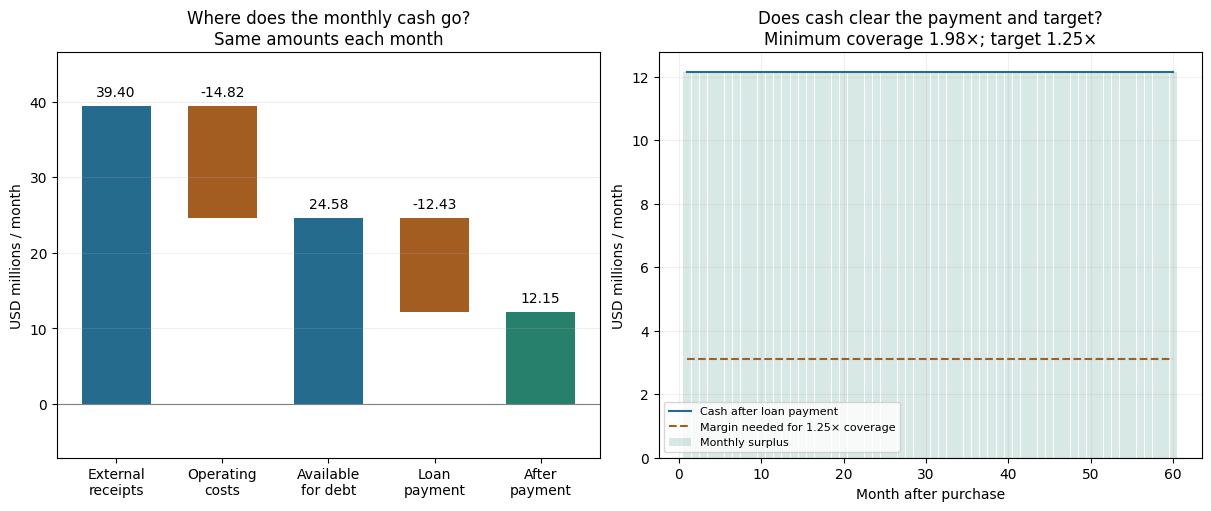

In [5]:
cfads = receipts - costs
print(f"Hand-worked DSCR: {cfads / payment:.2f}×")
display(plot_lab_case(base, view="cash"))

Base external receipts are USD 39.40 million/month, costs USD 14.82 million and CFADS USD 24.58 million. Coverage is **1.98×**. The left chart follows receipts through operating costs and the loan payment, leaving **USD 12.15 million/month**. The right chart compares that surplus with the **USD 3.11 million/month** margin needed above the payment to meet the 1.25× target. These are monthly amounts, not cumulative balances. They stay flat because the base case holds operations constant and uses equal loan payments. A red shortfall appears only when that month’s operating cash cannot cover its payment; cash can cover the payment yet still miss the higher coverage target. All post-debt surpluses remain in the project; no distributions occur. The operating buffer is the deepest cumulative deficit after retaining those surpluses, not the sum of every negative month.

## 4. What contracted share is enough?

Replacing a spot-eligible hour with a committed hour changes revenue and active cost. With fixed training, the incremental monthly CFADS per unit of contracted share is usable hours × [contract price − spot utilization × spot price − active cost × (1 − spot utilization)]. This allows an exact threshold, bounded by the capacity left after training. “Infeasible” means no allocation meets every month's coverage target under these assumptions.

CFADS gain per extra 1% committed: USD 590,976/month
Minimum committed share: 24.69%


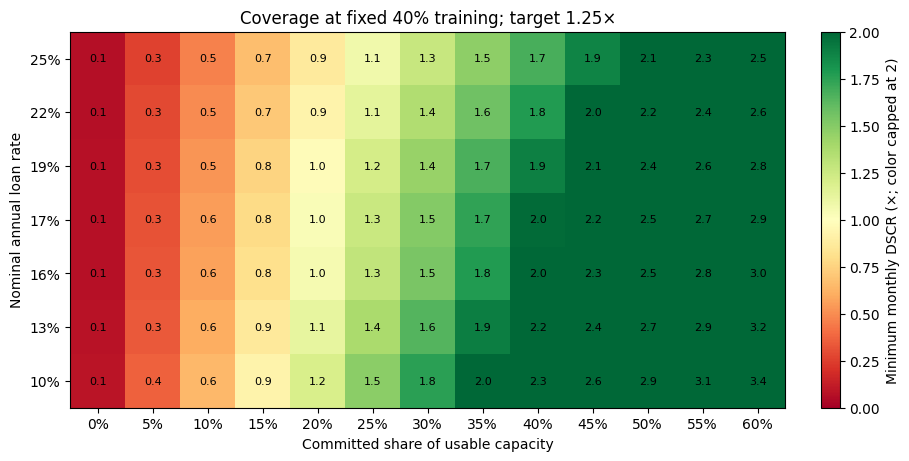

In [6]:
incremental_cfads_per_share = usable_hours * (
    base.contract_usd_per_gpu_hour
    - base.spot_utilization_fraction * base.spot_usd_per_gpu_hour
    - base.active_cost_usd_per_gpu_hour * (1 - base.spot_utilization_fraction)
)
print(
    f"CFADS gain per extra 1% committed: USD {incremental_cfads_per_share * 0.01:,.0f}/month"
)
threshold = minimum_contract_fraction(base)
print(
    "Minimum committed share:",
    "Infeasible" if threshold is None else f"{threshold:.2%}",
)
display(plot_lab_case(base, view="coverage"))

At 17% interest, **24.69% committed capacity** meets the 1.25× target while preserving 40% training, assuming the stated spot sales persist. This is not a contracted-revenue-only underwriting result. At the original 40% committed share, cash alone supports about USD 791.19 million of equal-payment debt; a separate 50% equipment advance ceiling limits selected borrowing to USD 500 million. These limits are compared, never added.

Raise training from 40% to 60% while holding committed sales at 40%. Spot sales disappear, and training costs rise. Coverage falls to 1.52×; the required committed share rises to 34.32%. The control below keeps all other baseline assumptions fixed. Values above 60% training conflict with the existing 40% commitment and display an input correction.

In [7]:
more_training = replace(base, training_fraction=0.60)
print(f"60% training DSCR: {model_lab(more_training).minimum_dscr:.2f}×")
display(lab_training_explorer(base))

60% training DSCR: 1.52×


The controls compare training allocation, committed capacity, spot price and loan rate. The readout tracks coverage, minimum commitment and additional cash. Switch the chart between cash, capacity and collateral to see which constraint changes. Training plus commitments above 100% is invalid: the chart clears until you correct the shares or reset. The fixed experiments below remain independent of these controls.

The lab can preserve 60% training in this particular base-price example, but has no spare capacity for spot rentals at the existing commitment. Higher training allocations require changing the committed contract too; the explorer never silently cancels it.

## 5. Collateral is a separate repayment protection

Assume first-priority enforceable equipment security. At a hypothetical default immediately **after** a scheduled payment, freeze remaining principal. Accrue simple interest during a six-month recovery delay; assume no further payments. Equipment value decays through that delay, then a 25% liquidation haircut and 10% selling cost apply. These are scenario assumptions, not appraisals, accounting depreciation or expected recoveries. The plot compares independent default dates, not one default followed by continued amortization.

Month-24 net sale / accrued claim: USD 229.93m / USD 378.16m
Equipment-only recovery: 60.8%


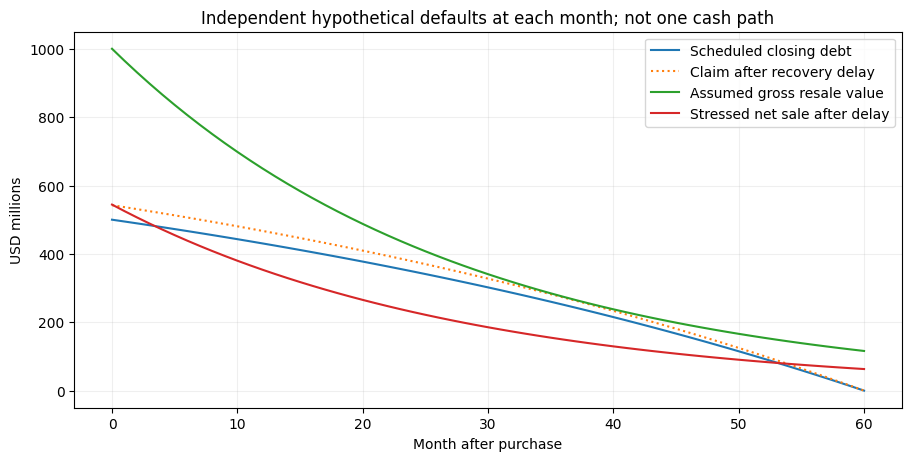

In [8]:
default_month = 24
net_sale = (
    base.equipment_usd
    * base.annual_value_retention_fraction
    ** ((default_month + base.recovery_delay_months) / 12)
    * (1 - base.liquidation_haircut_fraction)
    * (1 - base.selling_cost_fraction)
)
sale, claim, recovery = liquidation_stress(base, default_month=default_month)
print(
    f"Month-24 net sale / accrued claim: USD {sale / 1e6:.2f}m / USD {claim / 1e6:.2f}m"
)
print(f"Equipment-only recovery: {recovery / claim:.1%}")
display(plot_lab_case(base, view="collateral"))

Month-24 stressed proceeds are USD 229.93 million against a delayed claim of USD 378.16 million: **60.8% equipment-only recovery**. A low initial advance does not guarantee later coverage as equipment ages. This stress excludes cash balances, locked reserves, guarantees, prior arrears and enforcement expenses beyond the selling-cost assumption; it is not total estate recovery.

## 6. Compare cash needs, including the final repayment

Base and downside keep the same debt. Delay means six months with no usable capacity or revenue, while fixed costs and debt payments continue. Downside cuts spot price to USD 1/hour, utilization to 20%, and permanently loses committed receipts in months 13–15 while service costs continue. Severe adds the six-month delay, six lost-payment months (13–18), 10% spot utilization and 45% annual equipment value retention. No scenario probabilities are assumed.

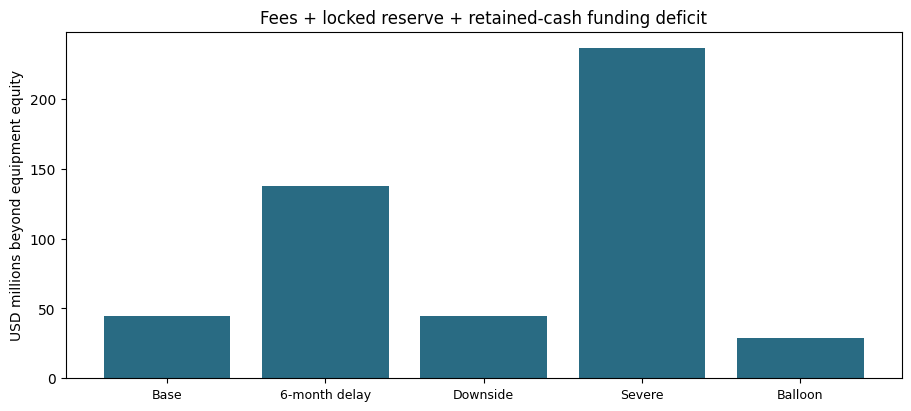

| Scenario | Extra cash USD m | Min DSCR | Scheduled ending debt USD m | Month-24 equipment recovery |
| --- | --- | --- | --- | --- |
| Base | 44.78 | 1.98× | 0.00 | 60.8% |
| 6-month delay | 137.34 | -0.24× | 0.00 | 60.8% |
| Downside | 44.78 | -1.06× | 0.00 | 60.8% |
| Severe | 236.30 | -1.07× | 0.00 | 24.2% |
| Balloon | 28.75 | 0.05× | 0.00 | 42.4% |

In [9]:
scenarios = {
    "Base": base,
    "6-month delay": replace(base, deployment_delay_months=6),
    "Downside": replace(
        base,
        spot_usd_per_gpu_hour=1,
        spot_utilization_fraction=0.20,
        interruption_months=3,
    ),
    "Severe": replace(
        base,
        deployment_delay_months=6,
        spot_usd_per_gpu_hour=1,
        spot_utilization_fraction=0.10,
        interruption_months=6,
        annual_value_retention_fraction=0.45,
    ),
    "Balloon": replace(base, repayment="balloon"),
}
display(plot_lab_scenarios(scenarios))
show_lab_scenario_comparison(scenarios, default_month=24)

Six months of delay require **USD 137.34 million beyond equipment equity**, including USD 92.56 million of operating/debt funding. Severe needs USD 236.30 million beyond purchase equity. The downside case breaches period coverage but needs no new operating buffer: previously retained surpluses absorb the lost receipts. That does not waive a covenant.

The balloon alternative pays interest monthly and USD 500 million of principal at maturity. Its final-month DSCR is only 0.048×, even though retained base-case surplus can cover the balloon in aggregate. A sinking-fund covenant would require a different sizing rule. No refinancing or sale is silently assumed. Scheduled ending debt is zero **only if all payments are funded**; this table is not a default/arrears simulation.

## Decision sheet

Keep cash sizing, collateral protection and support commitments separate. The selected loan is the smaller of the modeled cash limit and the proposed equipment advance ceiling. “Additional cash” includes the fee, locked reserve and operating buffer; support cash can fund only that buffer and never increases CFADS.

In [10]:
show_lab_decision_summary(base, default_month=24)

| Decision output | Base case |
| --- | --- |
| Minimum committed share at fixed training | 24.69% |
| Retained training | 40%; 8.755m GPU-hours/month |
| Cash-only loan limit | USD 791.19m |
| Loan within proposed advance ceiling | USD 500.00m |
| Additional cash beyond purchase equity | USD 44.78m |
| Operating funding gap after committed support | USD 0.00m |
| Month-24 equipment-only recovery | USD 229.93m |

The illustrative base cash flows cover the proposed loan, while deployment and equipment-value stresses expose different weaknesses. Before using real deal numbers, replace the assumptions with equipment specifications and delivered cost, available project cash, the actual training requirement, dated deployment and payment terms, operating budgets, customer conditions and remedies, security rights and independent resale evidence. Historical fundraising and a signed conditional offtake do not substitute for these inputs.

**Provenance and boundaries.** This is an original deterministic model responding to the user's pasted deal discussion (“what kind of concise jupyter notebook could we use to explore the financing of this deal”). No named lender appetite, customer credit quality, fundraising amount or external facility precedent has been verified or used as fact. Loan amortization reuses F1, coverage follows F4 and owned-equipment distinctions follow F8. All derived numbers above use the displayed defaults; editing inputs changes results, not this worked prose.

Rolling puts remain an extension after financing. A price hedge does not create customers for unsold hours; premiums, volume/basis mismatch and future roll availability need separate treatment in [M5](M5_calls_and_puts.ipynb) and [M7](M7_hedge_collateral_liquidity.ipynb). Return to the [canonical roadmap](README.md) for the full sequence.